In [30]:
pip install xgboost


You should consider upgrading via the '/Users/sindhu/Documents/code/ML/venv/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


In [7]:
df = sns.load_dataset("titanic")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
y = df["survived"]
y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: survived, Length: 891, dtype: int64

# Missing values

Bright lines in heatmap = missing values

Table shows exact numbers

Decision: impute median/most_frequent or drop heavily missing columns (deck)

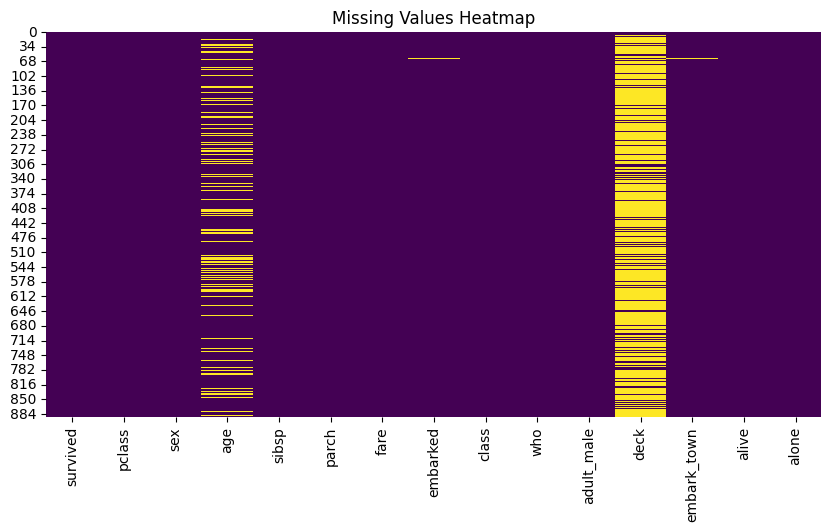

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

# Count missing
print(df.isnull().sum())


## Outliers

Outliers distort models like Logistic Regression & KNN.

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='object')


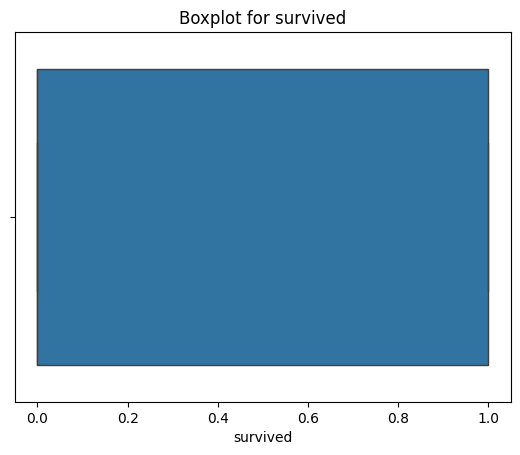

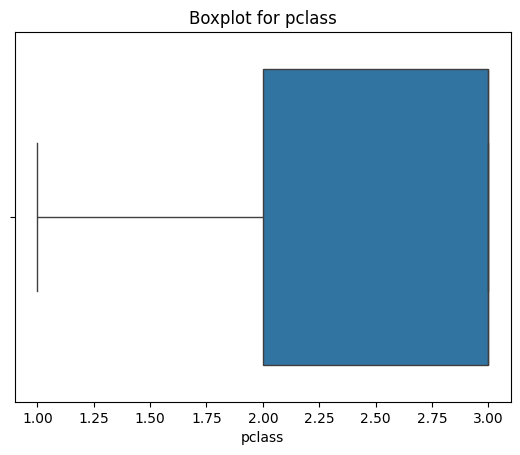

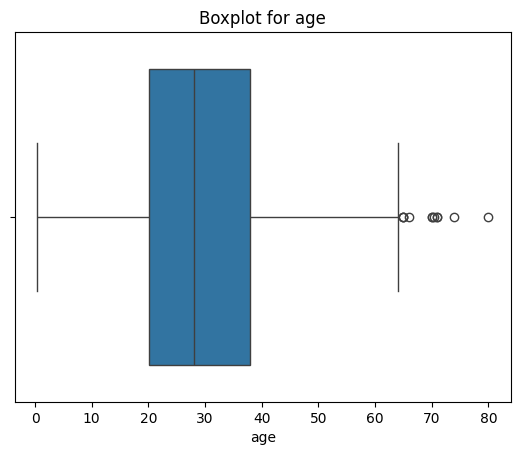

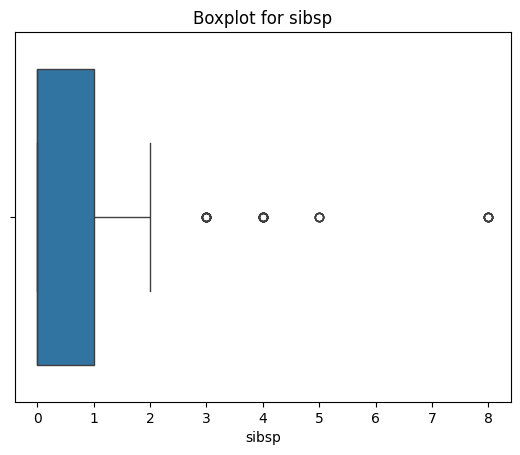

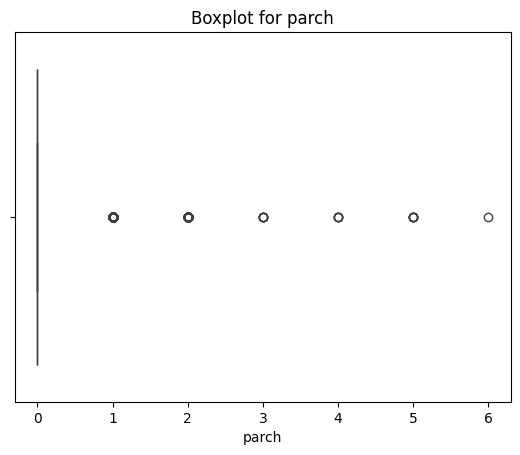

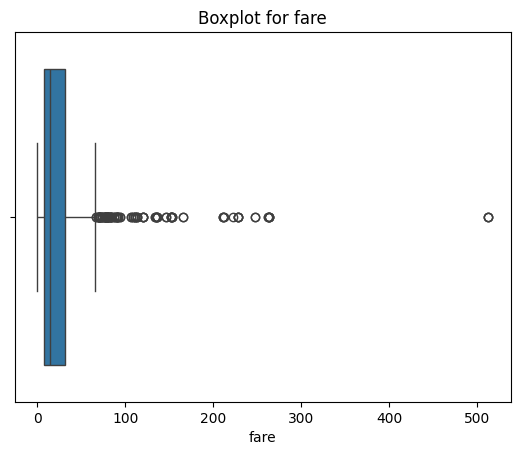

In [10]:
numeric_cols = df.select_dtypes(include=["float64","int64"]).columns
print(numeric_cols)
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot for {col}")
    plt.show()


Boxplot highlights extreme points (dots) outside the IQR whiskers

Example: fare has extreme high values → clip or log-transform

## Histogram for numeric  distribution
Histograms show skew visually

Skewed right → long tail to high values (fare)

Skewed left → long tail to low values

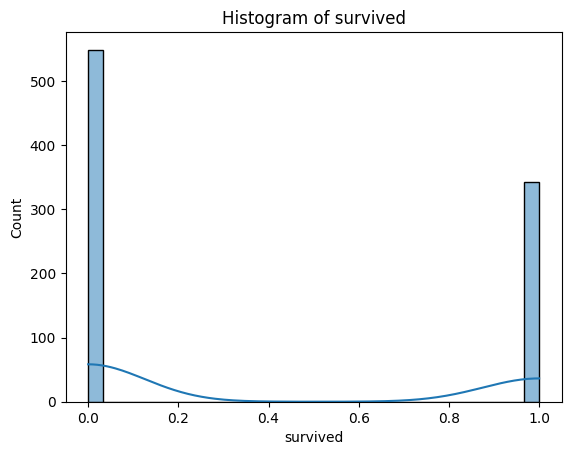

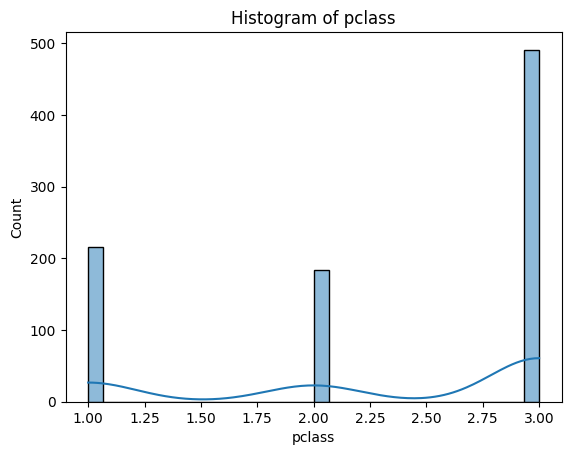

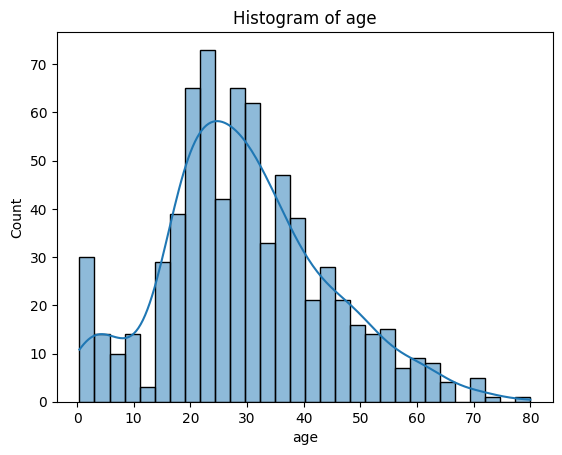

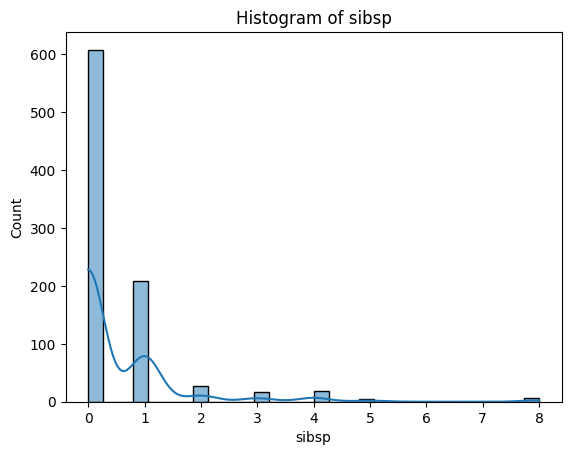

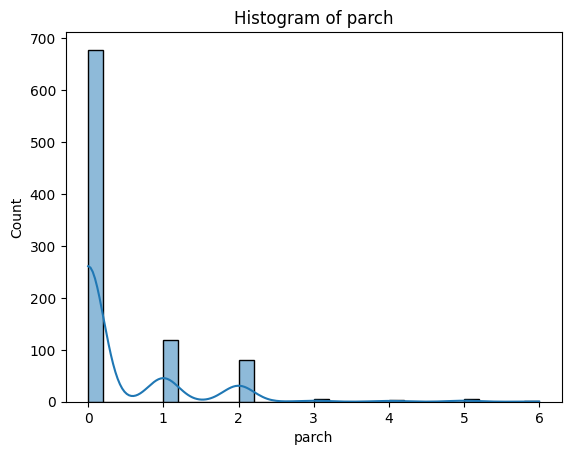

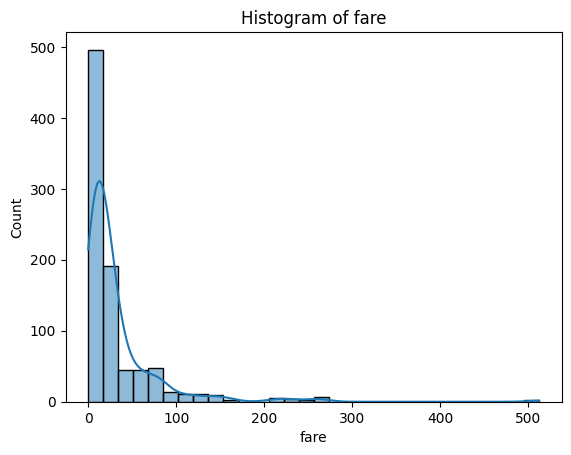

In [11]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

## SKEWNESS CHECK (Numeric)


Skewed features → gradient descent unstable, reduces predictive power

Logistic regression assumes roughly symmetric distributions

In [12]:
skew_values = df[numeric_cols].skew()
print("Skewness of numeric features:\n", skew_values)


Skewness of numeric features:
 survived    0.478523
pclass     -0.630548
age         0.389108
sibsp       3.695352
parch       2.749117
fare        4.787317
dtype: float64


## visualize skew fix


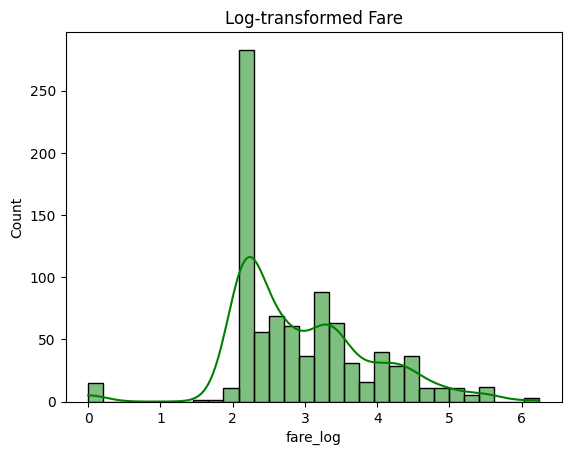

In [13]:
df["fare_log"] = np.log1p(df["fare"])

plt.figure()
sns.histplot(df["fare_log"], bins=30, kde=True, color="green")
plt.title("Log-transformed Fare")
plt.show()


## CATEGORICAL DATA EXPLORATION


Identify categorical features for encoding

Check frequency distribution

Imbalanced categories may influence encoding

Rare categories can be grouped or ignored (OneHotEncoder(handle_unknown='ignore'))

Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


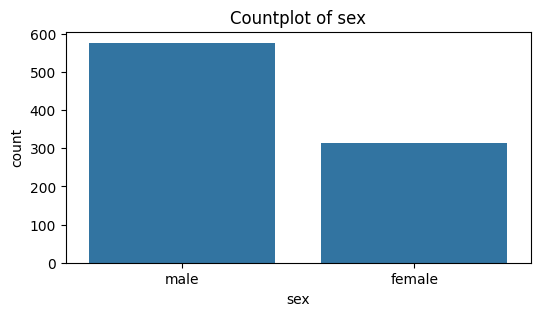

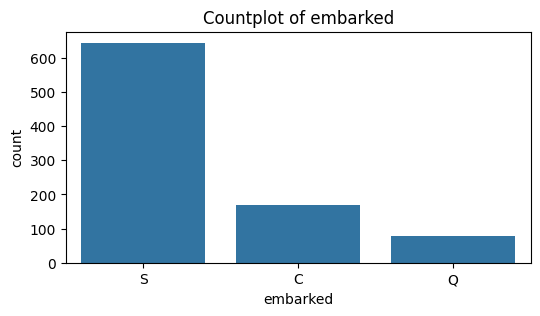

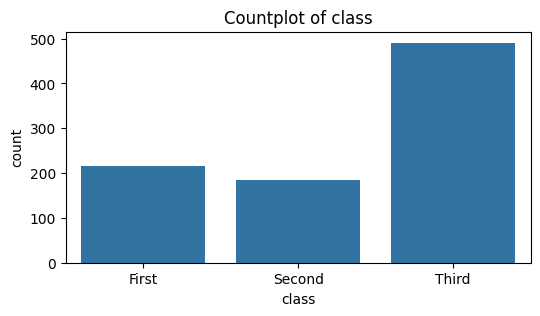

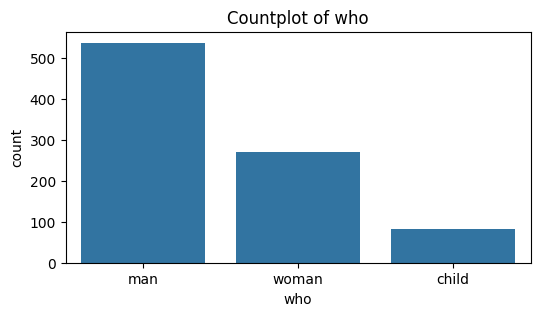

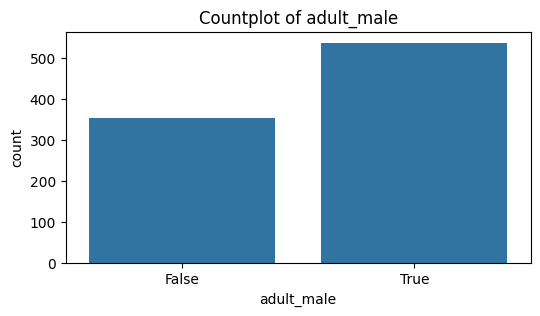

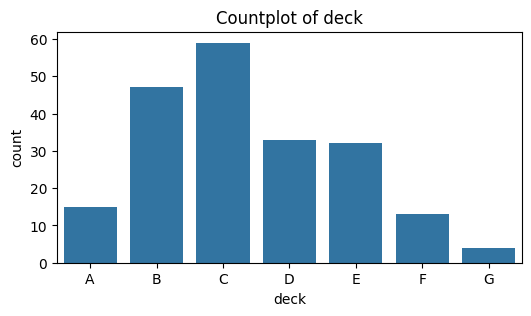

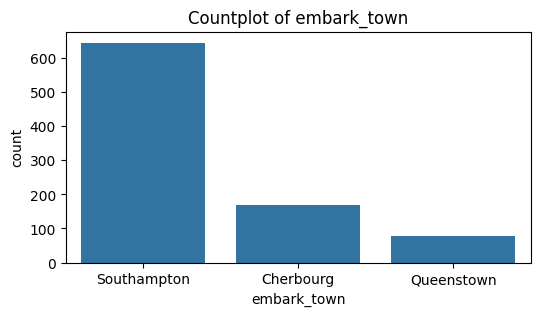

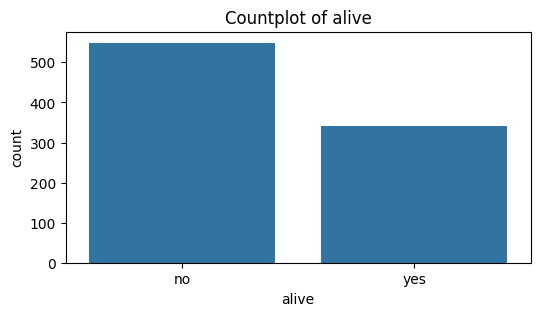

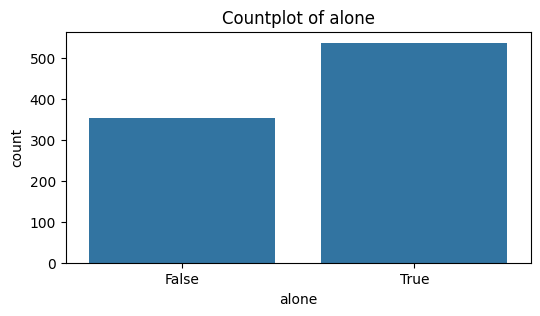

In [28]:
categorical_cols = df.select_dtypes(include=["object","category","bool"]).columns
print (categorical_cols)
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.show()


## FEATURE CORRELATION

Detect redundancy

Understand feature-target relationship

Strong correlation → useful for feature selection

Very low correlation → may be dropped

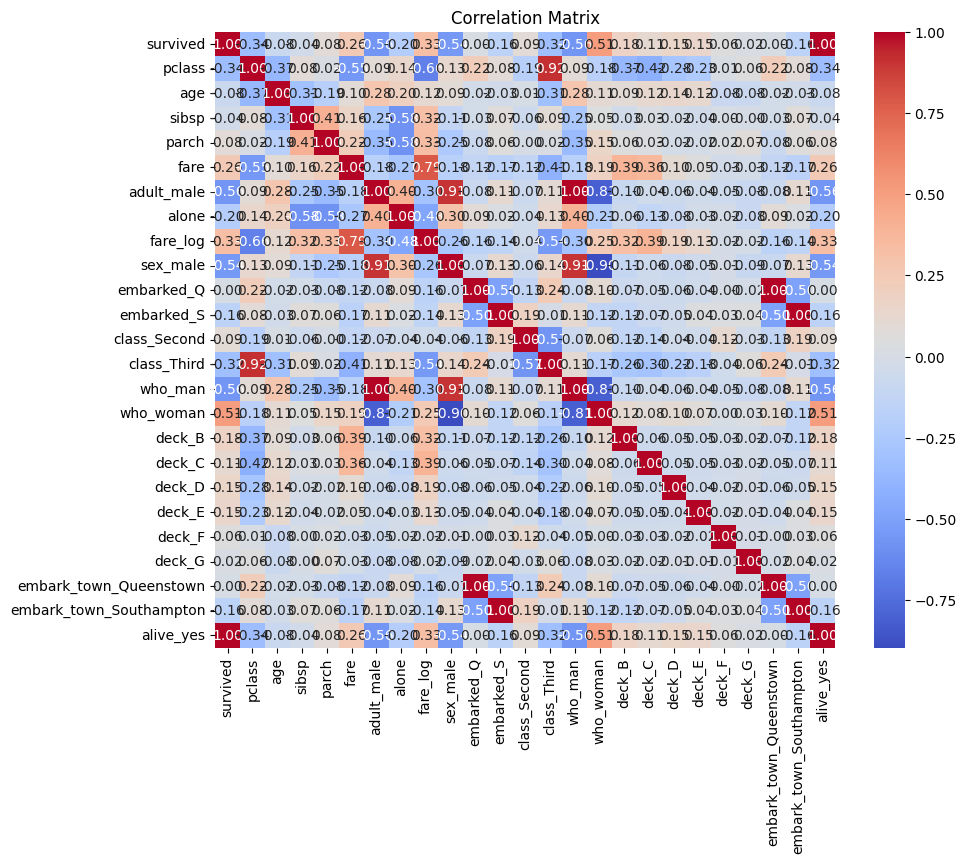

In [15]:
# Encoding categorical variables
import pandas as pd
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,8))
sns.heatmap(df_encoded.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


## outlier treatment

In [24]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class IQRClipper(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        X = np.asarray(X)
        
        Q1 = np.percentile(X, 25, axis=0)
        Q3 = np.percentile(X, 75, axis=0)
        IQR = Q3 - Q1
        
        self.lower_ = Q1 - 1.5 * IQR
        self.upper_ = Q3 + 1.5 * IQR
        
        return self
    
    def transform(self, X):
        X = np.asarray(X)
        return np.clip(X, self.lower_, self.upper_)



for categorical data, You’re wondering why we didn’t:

Scale categorical?

Detect outliers?

Transform skew?

Use target encoding?

Use frequency encoding?

Because:

Categorical data does NOT have:

Numeric magnitude

Distribution shape

Skewness

IQR-based outliers

Those apply only to numeric data.

It depends on score_func.

Different score functions measure different relationships between features and target.

🧪 Common Score Functions
For Classification
Function	Meaning
f_classif	ANOVA F-test;

chi2	Chi-square test;

mutual_info_classif	Mutual information

For Regression

f_regression	Correlation-based F-test;

mutual_info_regression	Nonlinear dependency

🚨 Important Limitation

SelectKBest is:

Univariate

Meaning:

It evaluates each feature independently.

It does NOT consider:

Feature interactions

Multicollinearity

Redundancy

🧠 When To Use It

Good for:

Linear models

High dimensional sparse data

Quick baseline filtering

Not ideal for:

Tree models (they handle feature importance internally)

Highly interacting features

In [27]:
#dropping the target variable : survived
# Numeric pipeline
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("survived")
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), #missing values
    ("outlier_clip", IQRClipper()), #outlier handling
    ("scaler", StandardScaler()) #scaling 
])

# Categorical pipeline
categorical_cols = df.select_dtypes(include=["object","category","bool"]).columns
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")), #mean doesnt make sense so we use most freq
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

# Feature Selection
selector = SelectKBest(score_func=f_classif, k=10)

# Model pipeline (example: Logistic)
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("feature_selection", selector),
    ("classifier", LogisticRegression(max_iter=1000))
])

# Train/Test
X = df.drop(columns="survived")
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, pred))


SelectKBest()
Final Accuracy: 1.0


/Users/sindhu/Documents/code/ML/venv/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [ 3 29 30] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/sindhu/Documents/code/ML/venv/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw
/Users/sindhu/Documents/code/ML/venv/lib/python3.9/site-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy')
    print(f"{name}: Mean CV Accuracy = {scores.mean():.3f}")


Logistic: Mean CV Accuracy = 1.000
KNN: Mean CV Accuracy = 0.948
RandomForest: Mean CV Accuracy = 1.000
XGBoost: Mean CV Accuracy = 1.000
